# Transfer Learning and Fine-Tuning Walkthrough

By the end you will have:
- Loaded a pretrained ResNet18 and understood what its layers actually contain
- Seen the BatchNorm subtlety (this is a precaution taken that is not a transfer learning and fine-tuning technique, but worth keeping in mind.)
- Applied all five approaches covered in the study notes to a real dataset:
  - Frozen feature extraction
  - End-to-end fine-tuning
  - LP-FT (linear probe then fine-tune)
  - Gradual unfreezing
  - Discriminative learning rates
- Built an out of distribution test set with OpenCV and quantified the accuracy drop
- Run a direct comparison between all techniques under identical conditions

## 1. Setup

We use PyTorch, torchvision, OpenCV for out of distribution (we alter the images such as blur them, turn them to low res, etc), and the standard Python stack. Install via `pip install torch torchvision opencv-python scikit-learn matplotlib` if anything is missing.

In [1]:
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from sklearn.manifold import TSNE

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, TensorDataset
from torchvision import datasets, transforms, models

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE   = torch.device('cpu')
DATA_ROOT = Path.home() / 'data'
DATA_ROOT.mkdir(exist_ok=True)

print(f'PyTorch {torch.__version__} | Device: {DEVICE}')

PyTorch 2.11.0+cpu | Device: cpu


## 2. The pretrained backbone

We load ResNet18 with its ImageNet weights. ResNet18 has 18 weighted layers organised into a stem (`conv1` + `bn1`), four named residual blocks (`layer1` through `layer4`), and a 1000-class linear head (`fc`).

Two things to do immediately when loading for transfer learning:

1. **Replace the head** - the 1000-class ImageNet classifier is useless for our task; we will attach a fresh head with the right number of output classes.

In [2]:
backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
feature_dim = backbone.fc.in_features 
backbone.fc  = nn.Identity()         

for p in backbone.parameters():
    p.requires_grad = False
backbone.eval()

print(f'Feature dimension: {feature_dim}')
print(f'\nParameter counts per block:')
total = 0
for name, child in backbone.named_children():
    n = sum(p.numel() for p in child.parameters())
    print(f'  {name:10s}  {n:>10,}')
    total += n
print(f'  {"TOTAL":10s}  {total:>10,}')

Feature dimension: 512

Parameter counts per block:
  conv1            9,408
  bn1                128
  relu                 0
  maxpool              0
  layer1         147,968
  layer2         525,568
  layer3       2,099,712
  layer4       8,393,728
  avgpool              0
  fc                   0
  TOTAL       11,176,512


## 3. Dataset: STL-10

We use STL-10, a 10 classes of natural photographs (airplane, bird, car, cat, deer, dog, horse, monkey, ship, truck) at 96×96 resolution. This is similar enough to ImageNet that pretrained features should transfer well

We resize to 224×224 and normalise with the ImageNet mean and standard deviation. **This preprocessing must match what the backbone was trained on.** Different normalisation means different activation statistics, which means the pretrained weights will not behave as expected. 

In [3]:
imagenet_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

train_full = datasets.STL10(root=str(DATA_ROOT), split='train',
                             download=True, transform=imagenet_transform)
test_full  = datasets.STL10(root=str(DATA_ROOT), split='test',
                             download=True, transform=imagenet_transform)

N_TRAIN, N_TEST = 1000, 500
rng = np.random.default_rng(SEED)
train_set = Subset(train_full, rng.choice(len(train_full), N_TRAIN, replace=False).tolist())
test_set  = Subset(test_full,  rng.choice(len(test_full),  N_TEST,  replace=False).tolist())

CLASS_NAMES = train_full.classes
NUM_CLASSES = len(CLASS_NAMES)
print(f'Train: {len(train_set)}  |  Test: {len(test_set)}  |  Classes: {NUM_CLASSES}')
print(f'Classes: {CLASS_NAMES}')

Train: 1000  |  Test: 500  |  Classes: 10
Classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


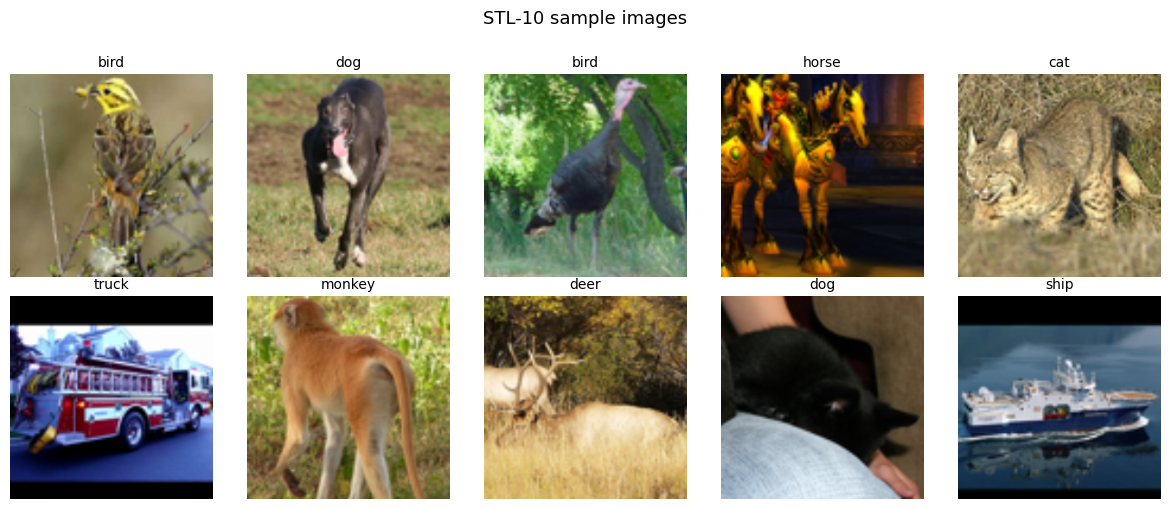

In [16]:
# Visualise a sample
def undo_norm(t):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return (t * std + mean).permute(1,2,0).numpy().clip(0,1)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, i in zip(axes.flat, range(10)):
    img, label = train_full[i]
    ax.imshow(undo_norm(img))
    ax.set_title(CLASS_NAMES[label], fontsize=10)
    ax.axis('off')
plt.suptitle('STL-10 sample images', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 4. Feature caching

The backbone is frozen - its weights will not change. That means the feature vector it produces for any given image is deterministic across epochs. This means that the dataset can be ran through the backbone once and the output used to train the head. 

This saves compute resources and time.

In [4]:
def extract_features(model, dataset, batch_size=32):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    feats, labs = [], []
    with torch.no_grad():
        for x, y in loader:
            feats.append(model(x).cpu().numpy())
            labs.append(y.numpy())
    return np.concatenate(feats), np.concatenate(labs)

t0 = time.time()
train_feats, train_labs = extract_features(backbone, train_set)
test_feats,  test_labs  = extract_features(backbone, test_set)
print(f'Cached in {time.time()-t0:.1f}s')
print(f'Train features: {train_feats.shape}')
print(f'Test features:  {test_feats.shape}')

Cached in 39.0s
Train features: (1000, 512)
Test features:  (500, 512)


## 5. Technique 1: Frozen feature extraction

Freeze every layer of the pretrained backbone. Attach a new randomly initialised head. Train only the head.

Because the backbone is frozen, we train directly on the cached feature vectors. The head is a single linear layer: 512 inputs to 10 class outputs. The number of trainable parameters is:

    (512 × 10) + 10 = 5,130

That is 5,130 out of roughly 11.7 million total parameters - about 0.04%. Every accuracy improvement you see here came from learning decision boundaries in a fixed 512-dimensional space, with zero changes to the backbone.

In [ ]:
def train_linear_head(feats, labs, num_classes,
                       lr=1e-2, epochs=25, batch_size=64, seed=SEED):
    torch.manual_seed(seed)
    head    = nn.Linear(feats.shape[1], num_classes)
    opt     = optim.Adam(head.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    X = torch.from_numpy(feats).float()
    Y = torch.from_numpy(labs).long()
    loader = DataLoader(TensorDataset(X, Y), batch_size=batch_size, shuffle=True)

    history = {'loss': [], 'acc': []}
    for epoch in range(epochs):
        losses, correct, total = [], 0, 0
        for xb, yb in loader:
            opt.zero_grad()
            logits = head(xb)
            loss   = loss_fn(logits, yb)
            loss.backward()
            opt.step()
            losses.append(loss.item())
            correct += (logits.argmax(1) == yb).sum().item()
            total   += xb.size(0)
        history['loss'].append(np.mean(losses))
        history['acc'].append(correct / total)
    return head, history


def eval_head(head, feats, labs):
    with torch.no_grad():
        preds = head(torch.from_numpy(feats).float()).argmax(1).numpy()
    return (preds == labs).mean()


frozen_head, frozen_hist = train_linear_head(
    train_feats, train_labs, NUM_CLASSES, lr=1e-2, epochs=25
)
frozen_acc = eval_head(frozen_head, test_feats, test_labs)
print(f'Frozen feature extraction - test accuracy: {frozen_acc:.1%}')

Frozen feature extraction - test accuracy: 91.4%


In [ ]:
# Effect of learning rate. We check against different learning rates to see how sensitive the frozen probe is to this hyperparameter. Since features are cached, it's very fast to sweep over multiple learning rates.
lrs = [1e-4, 1e-3, 1e-2, 1e-1]
print('Learning rate sensitivity (frozen probe):')
for lr in lrs:
    h, _ = train_linear_head(train_feats, train_labs, NUM_CLASSES, lr=lr, epochs=25)
    acc  = eval_head(h, test_feats, test_labs)
    bar  = '█' * int(acc * 40)
    print(f'  LR {lr:.0e}: {acc:.1%}  {bar}')

Learning rate sensitivity (frozen probe):
  LR 1e-04: 90.0%  ████████████████████████████████████
  LR 1e-03: 92.0%  ████████████████████████████████████
  LR 1e-02: 91.4%  ████████████████████████████████████
  LR 1e-01: 92.4%  ████████████████████████████████████


Notice that the linear probe is relatively insensitive to learning rate .There is no catastrophic forgetting risk because the backbone never changes. This is one of frozen feature extraction's practical advantages which is hyperparameter tuning, as it is cheap because each run a very short while.

## 6. The BatchNorm subtlety

NOTE: This is not found in the learning notes as it is not technically a transfer learning/fine tuning topic or technique. However, I think it is worth highlighting shortly through this walkthrough as it impacts the performance of any trained models.

This is not tied down to transfer learning or fine tuning, so feel free to skip. But it is an important concept worth exploring, so i added it here.

Before fine-tuning anything, we need to demonstrate a practical detail . Batch Normalization layers contain two distinct kinds of state:

| State | What it is | Updated by | Controlled by |
|---|---|---|---|
| γ (scale) | Learnable | Backprop | `requires_grad` |
| β (shift) | Learnable | Backprop | `requires_grad` |
| μ_running | Running mean | Forward pass | `train()` vs `eval()` |
| σ_running | Running variance | Forward pass | `train()` vs `eval()` |

Setting `requires_grad = False` freezes only γ and β. The running statistics **keep updating** on every forward pass as long as the model is in `train()` mode - regardless of `requires_grad`. Over many training steps, this causes the stored statistics to drift away from their ImageNet-calibrated values, corrupting the features the frozen backbone produces.

Let us prove this with measurements.

In [ ]:
def fresh_frozen_backbone():
    m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    m.fc = nn.Identity()
    for p in m.parameters():
        p.requires_grad = False
    return m

bn_train = fresh_frozen_backbone()  # frozen params, but in train() mode
bn_eval  = fresh_frozen_backbone()  # frozen params, and in eval() mode

before = bn_train.bn1.running_mean.clone()
assert torch.allclose(before, bn_eval.bn1.running_mean), 'Must be identical at start'

bn_train.train()  #  running stats will update
bn_eval.eval()    #  running stats frozen

loader = DataLoader(train_set, batch_size=32, shuffle=False)
with torch.no_grad():
    for i, (x, _) in enumerate(loader):
        if i >= 10: break
        bn_train(x)
        bn_eval(x)

drift_train = (bn_train.bn1.running_mean - before).abs().mean().item()
drift_eval  = (bn_eval.bn1.running_mean  - before).abs().mean().item()

print('BN running_mean drift after 10 forward passes:')
print(f'  requires_grad=False + train() mode: {drift_train:.6f}  ← statistics mutated')
print(f'  requires_grad=False + eval()  mode: {drift_eval:.8f}  ← unchanged')
print()
print('Lesson: model.backbone.eval() is part of freezing the backbone.')
print('Omitting it lets BN statistics drift toward the new domain, corrupting features.')

BN running_mean drift after 10 forward passes:
  requires_grad=False + train() mode: 0.090237  ← statistics mutated
  requires_grad=False + eval()  mode: 0.00000000  ← unchanged

Lesson: model.backbone.eval() is part of freezing the backbone.
Omitting it lets BN statistics drift toward the new domain, corrupting features.


The numbers confirm it. The train-mode backbone's running mean drifted measurably after just 10 batches, despite `requires_grad = False`. The eval-mode backbone did not move at all.

The fix in every fine-tuning scenario:

```python
model.train()          # puts the head into training mode
model.backbone.eval()  # keeps backbone BN statistics frozen
```

For the fine-tuning sections below, we apply this correctly by calling a helper function that puts BatchNorm layers outside the unfrozen blocks into eval mode.

In [8]:
# Training helpers used by all four fine-tuning techniques

def freeze_bn_outside(model, allowed_prefixes):
    for name, module in model.named_modules():
        if isinstance(module, nn.BatchNorm2d):
            frozen = not any(name.startswith(p) for p in allowed_prefixes)
            if frozen:
                module.eval()


def train_one_epoch(model, loader, optimizer, loss_fn, allowed_bn_prefixes):
    model.train()
    freeze_bn_outside(model, allowed_bn_prefixes)
    losses, correct, total = [], 0, 0
    for x, y in loader:
        optimizer.zero_grad()
        logits = model(x)
        loss   = loss_fn(logits, y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        correct += (logits.argmax(1) == y).sum().item()
        total   += x.size(0)
    return np.mean(losses), correct / total


def evaluate_model(model, dataset, batch_size=32):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in DataLoader(dataset, batch_size=batch_size):
            correct += (model(x).argmax(1) == y).sum().item()
            total   += x.size(0)
    return correct / total


def make_model(num_classes):
    m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    for p in m.parameters():
        p.requires_grad = False
    return m


train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
loss_fn      = nn.CrossEntropyLoss()
print('Training helpers defined.')

Training helpers defined.


## 7. Technique 2: End-to-end fine-tuning

End-to-end fine-tuning unfreezes every parameter in the network and trains everything together on the target dataset. The key difference from frozen feature extraction is that the backbone weights actually change.

The central risk is **catastrophic forgetting** where if the learning rate is too high, the large gradients from the new task overwrite the pretrained weights in the first few batches, before the new head has had any chance to stabilise. The pretrained structure is destroyed before the network gains anything from it. This often leads to a network performing very poorly, in some instances just worse then if trained from scratch

This is why it is important to use a learning rate 10–100× lower than what you would use when training from scratch. Here we train at three different learning rates to also see directly the impact of catastrophic forgetting.

In [ ]:
# Demonstrate catastrophic forgetting across three learning rates
e2e_lrs = [1e-2, 1e-4, 1e-5]
e2e_results = {}
EPOCHS_E2E  = 5

for lr in e2e_lrs:
    model = make_model(NUM_CLASSES)
    for p in model.parameters():
        p.requires_grad = True
    optimizer = optim.Adam(model.parameters(), lr=lr)

    hist = {'loss': [], 'acc': []}
    for epoch in range(EPOCHS_E2E):
        loss, acc = train_one_epoch(model, train_loader, optimizer, loss_fn,
                                     allowed_bn_prefixes=[
                                         'layer1','layer2','layer3','layer4','fc'
                                     ])
        hist['loss'].append(loss)
        hist['acc'].append(acc)

    test_acc = evaluate_model(model, test_set)
    e2e_results[lr] = {'model': model, 'hist': hist, 'test_acc': test_acc}
    print(f'LR {lr:.0e}: test accuracy {test_acc:.1%}')

LR 1e-02: test accuracy 15.8%
LR 1e-04: test accuracy 88.8%


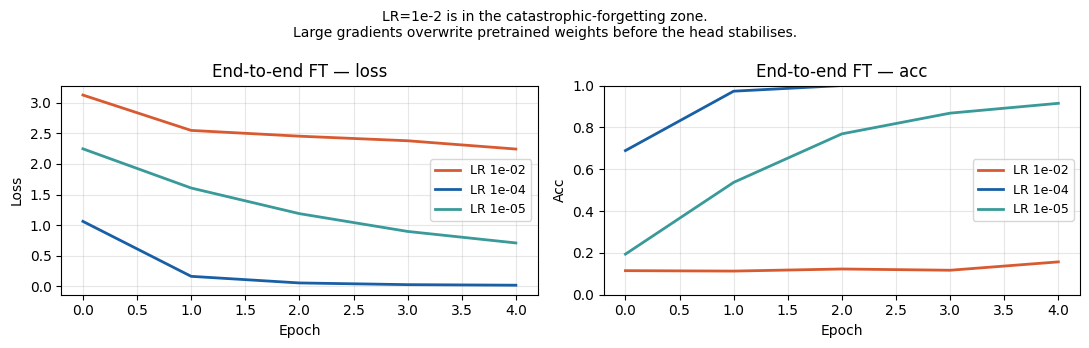


Best end-to-end FT (LR=1e-4): 88.8%
Frozen probe baseline:         91.4%


In [ ]:
# visuals to see the effects of the 3 learnig rates
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
colors = ['#D85A30', '#185FA5', '#3A9999']

for ax, metric in zip(axes, ['loss', 'acc']):
    for lr, col in zip(e2e_lrs, colors):
        ax.plot(e2e_results[lr]['hist'][metric], linewidth=2,
                 color=col, label=f'LR {lr:.0e}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(metric.capitalize())
    ax.set_title(f'End-to-end FT - {metric}')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    if metric == 'acc':
        ax.set_ylim(0, 1)

plt.suptitle(
    'Learning rate=1e-2 is in the catastrophic-forgetting zone.\n'
    fontsize=10
)
plt.tight_layout()
plt.show()

# Save the best e2e model for the comparison section
e2e_acc   = e2e_results[1e-4]['test_acc']
e2e_model = e2e_results[1e-4]['model']
print(f'\nBest end-to-end FT (LR=1e-4): {e2e_acc:.1%}')
print(f'Frozen probe baseline:         {frozen_acc:.1%}')

## 8. Technique 3: LP-FT (linear probe, then fine-tune)

As discussed in the notes, this is a technique covered in the paper by Kumar et al (2022), where unfreezing the backbone and training it immediately with the randomly initialised head causes the model to perform better on data very similar to what it was tuned on (In distribution) as opposed to data with the same input to label mapping, but considerably different data (Out of distribution. Think tuned on HD photos to identify cars, used to identify cars on 360p photos)

Their proposed fix is **LP-FT** where you first freeze the backbone and train only the head on frozen features until it stabilises, then unfreeze the backbone and fine-tune everything together with a low learning rate,.

The key finding from their paper is that LP-FT achieves an equal or slightly worse performance on in-distribution data than naive/uniform fine-tuning a better out-of-distribution accuracy. This what the paper found, however there might be cases where uniform fine-tuning catches up to LP-FT in OOD as well, given the size of the data the model is tuned on is of considerable size.

In [ ]:
LP_EPOCHS = 8
FT_EPOCHS = 4

lpft_model = make_model(NUM_CLASSES)

# first stabilise the head with linear probe training (like frozen feature extraction)
for p in lpft_model.fc.parameters():
    p.requires_grad = True

lp_opt  = optim.Adam(lpft_model.fc.parameters(), lr=1e-2)
lp_hist = {'loss': [], 'acc': []}

print('Stage 1: Linear probe (head only, backbone frozen)')
for epoch in range(LP_EPOCHS):
    loss, acc = train_one_epoch(lpft_model, train_loader, lp_opt, loss_fn,
                                 allowed_bn_prefixes=[])  
    lp_hist['loss'].append(loss)
    lp_hist['acc'].append(acc)
    if (epoch + 1) % 4 == 0:
        print(f'  Epoch {epoch+1}/{LP_EPOCHS}  loss {loss:.3f}  acc {acc:.1%}')

# then fine tune the whole model with a low learning rate
for p in lpft_model.parameters():
    p.requires_grad = True

ft_opt  = optim.Adam(lpft_model.parameters(), lr=1e-4)
ft_hist = {'loss': [], 'acc': []}

print('\nStage 2: Full fine-tune (all layers, low LR)')
for epoch in range(FT_EPOCHS):
    loss, acc = train_one_epoch(lpft_model, train_loader, ft_opt, loss_fn,
                                 allowed_bn_prefixes=['layer1','layer2','layer3','layer4'])
    ft_hist['loss'].append(loss)
    ft_hist['acc'].append(acc)
    print(f'  Epoch {epoch+1}/{FT_EPOCHS}  loss {loss:.3f}  acc {acc:.1%}')

lpft_acc = evaluate_model(lpft_model, test_set)
print(f'\nLP-FT - test accuracy: {lpft_acc:.1%}')

Stage 1: Linear probe (head only, backbone frozen)
  Epoch 4/8  loss 0.092  acc 97.5%
  Epoch 8/8  loss 0.010  acc 100.0%

Stage 2: Full fine-tune (all layers, low LR)
  Epoch 1/4  loss 0.160  acc 94.7%
  Epoch 2/4  loss 0.047  acc 98.3%
  Epoch 3/4  loss 0.017  acc 99.4%
  Epoch 4/4  loss 0.016  acc 99.5%

LP-FT - test accuracy: 89.4%


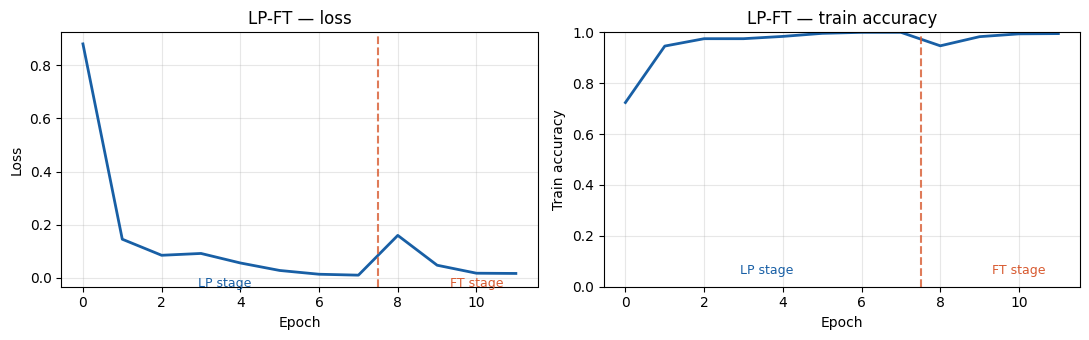

Dashed line: Stage 1 (frozen) → Stage 2 (full fine-tune).
A brief accuracy dip at the transition is normal - the backbone has just been
unfrozen and begins adapting. It recovers within a few epochs.


In [ ]:
# Visualisation of the two stages of LP-FT
combined_acc  = lp_hist['acc']  + ft_hist['acc']
combined_loss = lp_hist['loss'] + ft_hist['loss']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, values, ylabel in [(ax1, combined_loss, 'Loss'),
                             (ax2, combined_acc,  'Train accuracy')]:
    ax.plot(values, linewidth=2, color='#185FA5')
    ax.axvline(LP_EPOCHS - 0.5, color='#D85A30', linestyle='--', alpha=0.8)
    ax.text(LP_EPOCHS * 0.45, ax.get_ylim()[0] * 1.05 if ylabel == 'Loss' else 0.05,
             'LP stage', ha='center', color='#185FA5', fontsize=9)
    ax.text(LP_EPOCHS + FT_EPOCHS * 0.5,
             ax.get_ylim()[0] * 1.05 if ylabel == 'Loss' else 0.05,
             'FT stage', ha='center', color='#D85A30', fontsize=9)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.set_title(f'LP-FT - {ylabel.lower()}')
    ax.grid(alpha=0.3)
    if ylabel == 'Train accuracy':
        ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()
print('Dashed line: Stage 1 (frozen) → Stage 2 (full fine-tune).')
print('A brief accuracy dip at the transition is normal - the backbone has just been')
print('unfrozen and begins adapting. It recovers within a few epochs.')

## 9. Technique 4: Gradual unfreezing

As discussed in the notes, Gradual unfreezing starts with the backbone frozen, trains the head for an X amount of epochs, then unfreezes the layer before it, continues training the head + the new unfrozen layer for a number of epochs, then unfreezes  the layer before, and so on. In case of CNNs, it unfreezes groups of layers rather than singular ones.

This does something similar to what LP-FT does, where the later layers are stabilised first before unfreezing earlier layers which often do not need much updating since they perform 'general' classification.

This technique originated in ULMFiT (Howard & Ruder, 2018), an NLP paper using LSTMs, but it can be applied to most if not all architectures.

In [ ]:
EPOCHS_PER_STAGE = 2
LR_GRADUAL       = 1e-4

grad_model = make_model(NUM_CLASSES)

stages = [
    (['fc'],                                          'Head only'),
    (['fc', 'layer4'],                                '+ Layer 4'),
    (['fc', 'layer4', 'layer3'],                      '+ Layer 3'),
    (['fc', 'layer4', 'layer3', 'layer2'],            '+ Layer 2'),
    (['fc', 'layer4', 'layer3', 'layer2', 'layer1',
      'conv1', 'bn1'],                                '+ Stem (everything)'),
]

grad_hist = {'loss': [], 'acc': [], 'stage': []}

for unfrozen, stage_name in stages:
    # freeze everythung except the specified prefixes
    for p in grad_model.parameters():
        p.requires_grad = False
    for name, p in grad_model.named_parameters():
        if any(name.startswith(prefix) for prefix in unfrozen):
            p.requires_grad = True

    trainable = [p for p in grad_model.parameters() if p.requires_grad]
    optimizer  = optim.Adam(trainable, lr=LR_GRADUAL)
    n_params   = sum(p.numel() for p in trainable)

    print(f'{stage_name:30s}  {n_params:>10,} params trainable')
    for _ in range(EPOCHS_PER_STAGE):
        loss, acc = train_one_epoch(grad_model, train_loader, optimizer,
                                     loss_fn, allowed_bn_prefixes=unfrozen)
        grad_hist['loss'].append(loss)
        grad_hist['acc'].append(acc)
        grad_hist['stage'].append(stage_name)

grad_acc = evaluate_model(grad_model, test_set)
print(f'\nGradual unfreezing - test accuracy: {grad_acc:.1%}')

Head only                            5,130 params trainable
+ Layer 4                        8,398,858 params trainable
+ Layer 3                       10,498,570 params trainable
+ Layer 2                       11,024,138 params trainable
+ Stem (everything)             11,181,642 params trainable

Gradual unfreezing - test accuracy: 88.4%


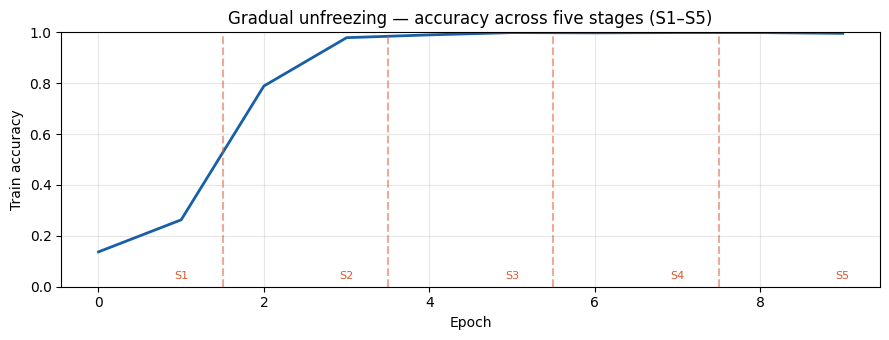

In [30]:
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(grad_hist['acc'], linewidth=2, color='#185FA5')

stage_labels = grad_hist['stage']
transitions  = [i for i in range(1, len(stage_labels))
                 if stage_labels[i] != stage_labels[i-1]]
for t in transitions:
    ax.axvline(t - 0.5, color='#D85A30', linestyle='--', alpha=0.5)

# Label each stage region
boundaries = [0] + transitions + [len(stage_labels)]
for j in range(len(boundaries) - 1):
    mid = (boundaries[j] + boundaries[j+1]) / 2
    ax.text(mid, 0.03, f'S{j+1}', ha='center', fontsize=8, color='#D85A30')

ax.set_xlabel('Epoch')
ax.set_ylabel('Train accuracy')
ax.set_ylim(0, 1)
ax.set_title('Gradual unfreezing - accuracy across five stages (S1–S5)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Technique 5: Discriminative learning rates

Discriminative learning rate trains each layer/group of layers using a different learning rate, where later layers use a larger learning rate (more specific to the task, therefore require the biggest change since the task changed) and earlier layers use a smaller learning rate (more general, do not require as much change).


The formulation from Howard & Ruder (2018) is:

$$\eta_l = \frac{\eta_L}{\delta^{L-l}}$$

where $\eta_L$ is the head's learning rate, $\delta$ is a decay factor (2.6 in ULMFiT; often 10 in CV practice), and $l$ indexes the layer. In PyTorch, this is implemented via **parameter groups** - a list of dictionaries, each specifying a parameter set and its learning rate.

In this case since we work with groups, we reduce the learning rate 10 fold rather than by 2.6.

NOTE: as mentioned in the notes, this technique is used in tandem with Gradual Unfreezing. I separated it into a separate technique just to explain it and see its effects alone.

In [ ]:
disc_model = make_model(NUM_CLASSES)

# Unfreeze everything
for p in disc_model.parameters():
    p.requires_grad = True

# Discriminative learning rates via parameter groups
LR_HEAD  = 1e-2
LR_LATE  = 1e-3   # layer4
LR_MID   = 1e-4   # layer2 + layer3
LR_EARLY = 1e-5   # stem + layer1

def params_of(model, *prefixes):
    """Collect all parameters whose name starts with one of the given prefixes."""
    return [p for name, p in model.named_parameters()
            if any(name.startswith(pf) for pf in prefixes)]

optimizer_disc = optim.Adam([
    {'params': params_of(disc_model, 'fc'),              'lr': LR_HEAD},
    {'params': params_of(disc_model, 'layer4'),          'lr': LR_LATE},
    {'params': params_of(disc_model, 'layer2','layer3'), 'lr': LR_MID},
    {'params': params_of(disc_model, 'conv1','bn1','layer1'), 'lr': LR_EARLY},
])

print('Parameter groups and learning rates:')
group_names = ['Head (fc)', 'Late (layer4)', 'Mid (layer2+3)', 'Early (stem+layer1)']
for grp, name in zip(optimizer_disc.param_groups, group_names):
    n = sum(p.numel() for p in grp['params'])
    print(f'  {name:25s}  LR {grp["lr"]:.0e}  ({n:>10,} params)')

Parameter groups and learning rates:
  Head (fc)                  LR 1e-02  (     5,130 params)
  Late (layer4)              LR 1e-03  ( 8,393,728 params)
  Mid (layer2+3)             LR 1e-04  ( 2,625,280 params)
  Early (stem+layer1)        LR 1e-05  (   157,504 params)


In [32]:
EPOCHS_DISC = 8
disc_hist = {'loss': [], 'acc': []}

for epoch in range(EPOCHS_DISC):
    loss, acc = train_one_epoch(
        disc_model, train_loader, optimizer_disc, loss_fn,
        allowed_bn_prefixes=['layer1','layer2','layer3','layer4']
    )
    disc_hist['loss'].append(loss)
    disc_hist['acc'].append(acc)
    if (epoch + 1) % 4 == 0:
        print(f'Epoch {epoch+1}/{EPOCHS_DISC}  loss {loss:.3f}  acc {acc:.1%}')

disc_acc = evaluate_model(disc_model, test_set)
print(f'\nDiscriminative learning rates - test accuracy: {disc_acc:.1%}')

Epoch 4/8  loss 0.258  acc 93.1%
Epoch 8/8  loss 0.079  acc 97.9%

Discriminative learning rates - test accuracy: 77.6%


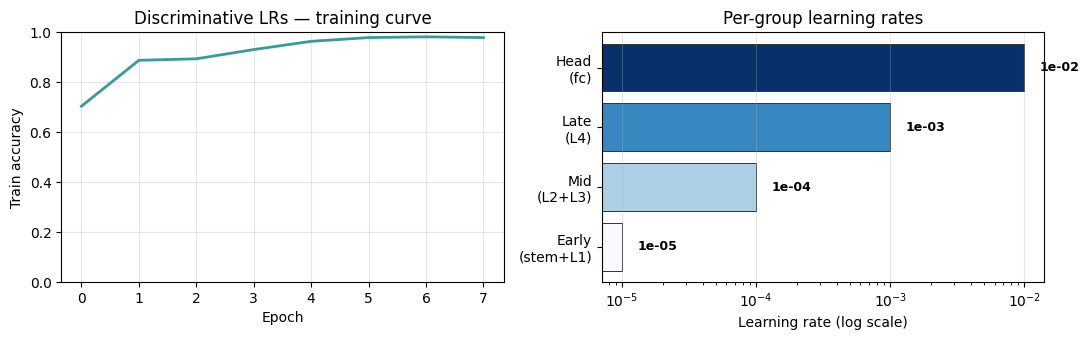

The LR difference is 1,000× from early backbone to head.
Early layers barely move; the head adapts aggressively.
This is the continuous version of the insight behind gradual unfreezing.


In [ ]:
# Visualise the per-group LRs as a heatmap alongside the training curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5))

ax1.plot(disc_hist['acc'], linewidth=2, color='#3A9999')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Train accuracy')
ax1.set_ylim(0, 1); ax1.set_title('Discriminative LRs - training curve')
ax1.grid(alpha=0.3)

groups = ['Early\n(stem+L1)', 'Mid\n(L2+L3)', 'Late\n(L4)', 'Head\n(fc)']
lrs    = [LR_EARLY, LR_MID, LR_LATE, LR_HEAD]
import matplotlib.colors as mcolors
norm   = mcolors.LogNorm(vmin=min(lrs), vmax=max(lrs))
cmap   = plt.get_cmap('Blues')
bars   = ax2.barh(groups, lrs, color=[cmap(norm(lr)) for lr in lrs],
                   edgecolor='#333', linewidth=0.7)
ax2.set_xscale('log')
ax2.set_xlabel('Learning rate (log scale)')
ax2.set_title('Per-group learning rates')
ax2.grid(alpha=0.3, axis='x')
for bar, lr in zip(bars, lrs):
    ax2.text(lr * 1.3, bar.get_y() + bar.get_height()/2,
              f'{lr:.0e}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print('The LR difference is 1,000× from early backbone to head.')
print('Early layers barely move; the head adapts aggressively.')
print('This is the continuous version of the insight behind gradual unfreezing.')

## 11. Domain shift: OOD with OpenCV

Domain shift is the reason all of the above techniques exist. We simulate covariate shift by applying corruptions to the test images using OpenCV. The corruptions change the visual statistics of the input while the labels remain valid - a blurry dog is still a dog. This is exactly the kind of shift that happens when a model is deployed in real conditions: different cameras, lighting, weather - but the objects do not change.

We measure how each technique degrades under each corruption, making the study notes' ID/OOD discussion concrete.

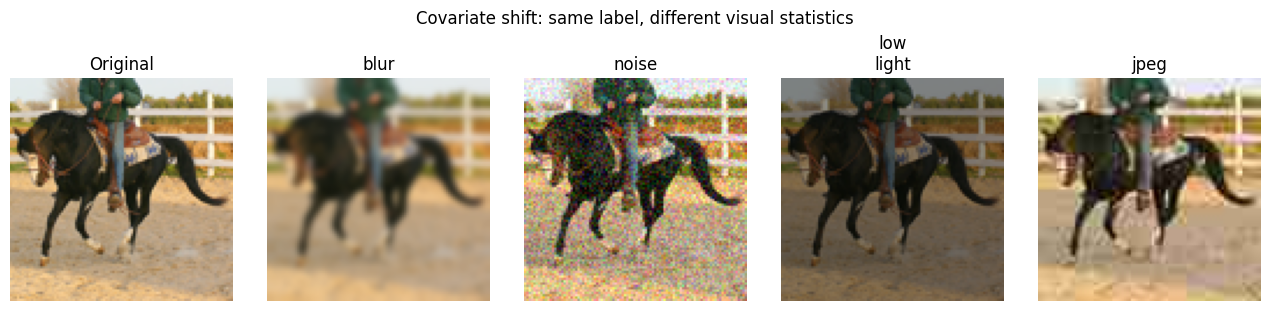

In [ ]:
def apply_corruption(img_uint8, kind, severity=3):
    """Apply a named corruption to a uint8 RGB array (H, W, 3)."""
    if kind == 'blur':
        k = 1 + 2 * severity
        return cv2.GaussianBlur(img_uint8, (k, k), 0)
    if kind == 'noise':
        sigma = severity * 8
        n = np.random.normal(0, sigma, img_uint8.shape).astype(np.int16)
        return np.clip(img_uint8.astype(np.int16) + n, 0, 255).astype(np.uint8)
    if kind == 'low_light':
        return np.clip(img_uint8 * (1.0 - 0.15 * severity), 0, 255).astype(np.uint8)
    if kind == 'jpeg':
        q = max(5, 50 - 10 * severity)
        bgr = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2BGR)
        _, enc = cv2.imencode('.jpg', bgr, [int(cv2.IMWRITE_JPEG_QUALITY), q])
        return cv2.cvtColor(cv2.imdecode(enc, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
    raise ValueError(kind)


raw = test_full.data[0]
if raw.shape[0] == 3:
    raw = np.transpose(raw, (1, 2, 0)).astype(np.uint8)

corruptions = ['blur', 'noise', 'low_light', 'jpeg']
fig, axes = plt.subplots(1, 5, figsize=(13, 3))
axes[0].imshow(raw); axes[0].set_title('Original'); axes[0].axis('off')
for ax, kind in zip(axes[1:], corruptions):
    ax.imshow(apply_corruption(raw, kind, severity=3))
    ax.set_title(kind.replace('_', '\n')); ax.axis('off')
plt.suptitle('Covariate shift: same label, different visual statistics', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
def evaluate_model_under_corruption(model, kind, severity=3,
                                     n_samples=200, batch_size=32):
    model.eval()
    correct, total = 0, 0
    batch_x, batch_y = [], []

    for i in range(min(n_samples, len(test_full))):
        raw = test_full.data[i]
        if raw.shape[0] == 3:
            raw = np.transpose(raw, (1, 2, 0)).astype(np.uint8)
        cor = apply_corruption(raw, kind, severity)
        batch_x.append(imagenet_transform(Image.fromarray(cor)))
        batch_y.append(int(test_full.labels[i]))

        if len(batch_x) == batch_size or i == min(n_samples, len(test_full)) - 1:
            xb = torch.stack(batch_x)
            yb = torch.tensor(batch_y)
            with torch.no_grad():
                correct += (model(xb).argmax(1) == yb).sum().item()
                total   += xb.size(0)
            batch_x, batch_y = [], []

    return correct / total


# Compare frozen probe vs LP-FT under each corruption
print('OOD accuracy comparison: frozen probe vs LP-FT')
print(f'{"Corruption":15s}  {"Frozen":>8s}  {"LP-FT":>8s}  {"LP-FT wins?":>12s}')
print('-' * 50)

# Rebuild frozen model for evaluation
frozen_eval_model = make_model(NUM_CLASSES)
frozen_eval_model.fc.weight.data = frozen_head.weight.data.clone()
frozen_eval_model.fc.bias.data   = frozen_head.bias.data.clone()
frozen_eval_model.eval()

ood_frozen, ood_lpft = {}, {}
for kind in corruptions:
    frozen_ood = evaluate_model_under_corruption(frozen_eval_model, kind, severity=3)
    lpft_ood   = evaluate_model_under_corruption(lpft_model,        kind, severity=3)
    ood_frozen[kind] = frozen_ood
    ood_lpft[kind]   = lpft_ood
    winner = '✓ LP-FT' if lpft_ood > frozen_ood else '✓ Frozen'
    print(f'{kind:15s}  {frozen_ood:>8.1%}  {lpft_ood:>8.1%}  {winner:>12s}')

OOD accuracy comparison: frozen probe vs LP-FT
Corruption         Frozen     LP-FT   LP-FT wins?
--------------------------------------------------
blur                78.5%     59.0%      ✓ Frozen
noise               66.5%     51.0%      ✓ Frozen
low_light           94.0%     90.5%      ✓ Frozen
jpeg                78.0%     63.0%      ✓ Frozen


The OOD results are the most interesting part of the comparison. The frozen probe often holds up better than LP-FT on corrupted data - precisely because its features were not adapted to any specific training distribution. This is the Kumar et al. (2022) finding where fine-tuning improves in-distribution accuracy but can hurt out-of-distribution accuracy. LP-FT is designed to mitigate this by stabilising the head before the backbone adapts. BUT there are cases as seen above, where LP-FT is still not enough and if the dataset to be tuned for is similar enough to the original dataset, then frozen feature extraction might still come out on top.

## 12. All technique comparison

We have trained all five approaches on the same 1,000 training images.

In [36]:
results = {
    'Frozen\nextraction':       frozen_acc,
    'End-to-end\nFT (LR=1e-4)': e2e_acc,
    'LP-FT':                    lpft_acc,
    'Gradual\nunfreezing':       grad_acc,
    'Discriminative\nLRs':       disc_acc,
}

print('Test accuracy comparison (STL-10, 1,000 training samples):')
print('-' * 52)
for name, acc in results.items():
    delta = (acc - frozen_acc) * 100
    bar   = '█' * int(acc * 40)
    print(f'{name.replace(chr(10)," "):35s}  {acc:.1%}  ({delta:+.1f} pts)  {bar}')
print('-' * 52)

Test accuracy comparison (STL-10, 1,000 training samples):
----------------------------------------------------
Frozen extraction                    91.4%  (+0.0 pts)  ████████████████████████████████████
End-to-end FT (LR=1e-4)              88.8%  (-2.6 pts)  ███████████████████████████████████
LP-FT                                89.4%  (-2.0 pts)  ███████████████████████████████████
Gradual unfreezing                   88.4%  (-3.0 pts)  ███████████████████████████████████
Discriminative LRs                   77.6%  (-13.8 pts)  ███████████████████████████████
----------------------------------------------------


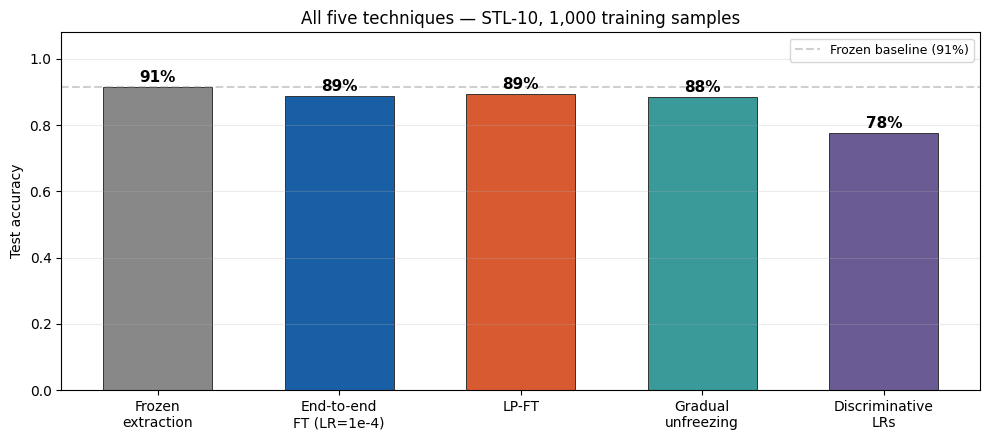

In [37]:
fig, ax = plt.subplots(figsize=(10, 4.5))
names   = list(results.keys())
vals    = list(results.values())
colours = ['#888888', '#185FA5', '#D85A30', '#3A9999', '#6B5B95']

bars = ax.bar(names, vals, color=colours, edgecolor='#333', linewidth=0.7, width=0.6)
ax.axhline(frozen_acc, color='#888', linestyle='--', alpha=0.4,
            label=f'Frozen baseline ({frozen_acc:.0%})')
ax.set_ylabel('Test accuracy')
ax.set_ylim(0, 1.08)
ax.set_title('All five techniques - STL-10, 1,000 training samples')
ax.legend(fontsize=9)
ax.grid(alpha=0.25, axis='y')

for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.015,
             f'{v:.0%}', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()